In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
G = nx.florentine_families_graph()

In [ ]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 15
Number of edges: 20


In [19]:
degree_dict = dict(G.degree())
degrees = list(degree_dict.values())
density = nx.density(G)
components = list(nx.connected_components(G))

print(f"Density: {density:.4f}")
print(f"Connected components: {len(components)}")
print(f"Minimum degree: {min(degrees)}")
print(f"Maximum degree: {max(degrees)}")
print(f"Average degree: {sum(degrees) / len(degrees):.2f}")

Density: 0.1905
Connected components: 1
Minimum degree: 1
Maximum degree: 6
Average degree: 2.67


In [ ]:
metrics_table = pd.DataFrame({
    "Metric": [
        "Nodes",
        "Edges",
        "Density",
        "Connected Components",
        "Minimum Degree",
        "Maximum Degree",
        "Average Degree"
    ],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        round(density, 4),
        len(components),
        min(degrees),
        max(degrees),
        round(sum(degrees) / len(degrees), 2)
    ]
})

print("MAIN METRICS TABLE")
print(metrics_table)

MAIN METRICS TABLE
                 Metric    Value
0                 Nodes  15.0000
1                 Edges  20.0000
2               Density   0.1905
3  Connected Components   1.0000
4        Minimum Degree   1.0000
5        Maximum Degree   6.0000
6        Average Degree   2.6700


In [ ]:
degree_table = pd.DataFrame({
    "Family": list(degree_dict.keys()),
    "Degree": list(degree_dict.values())
}).sort_values(by="Degree", ascending=False)

print("DEGREE TABLE")
print(degree_table)

DEGREE TABLE
          Family  Degree
1         Medici       6
4        Strozzi       4
12      Guadagni       4
6        Ridolfi       3
3        Peruzzi       3
7     Tornabuoni       3
2     Castellani       3
11      Bischeri       3
8        Albizzi       3
9       Salviati       2
5      Barbadori       2
0     Acciaiuoli       1
10         Pazzi       1
13        Ginori       1
14  Lamberteschi       1


In [ ]:
source = "Medici"
target = "Strozzi"
path = nx.shortest_path(G, source=source, target=target)

print("EXAMPLE PATH")
print(f"Shortest path from {source} to {target}:")
print(" -> ".join(path))

EXAMPLE PATH
Shortest path from Medici to Strozzi:
Medici -> Ridolfi -> Strozzi


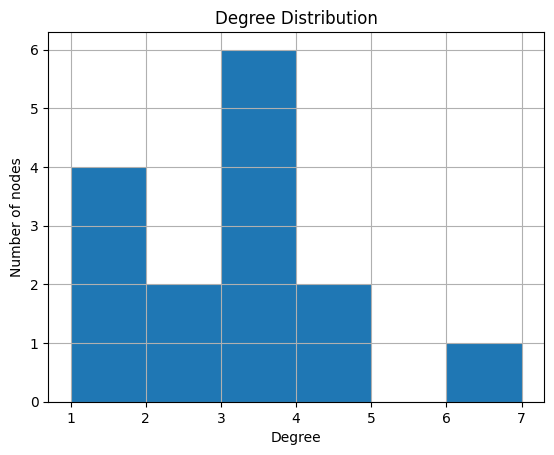

In [ ]:
plt.figure()
plt.hist(degrees, bins=range(min(degrees), max(degrees)+2))
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.grid()
plt.show()

In [ ]:
cycles = nx.cycle_basis(G)
example_cycle = cycles[0]

print("CYCLE")
print(" -> ".join(example_cycle + [example_cycle[0]]))

CYCLE
Peruzzi -> Strozzi -> Bischeri -> Peruzzi


In [ ]:
print("ADJACENCY LIST")
for node in list(G.nodes())[:5]:
    print(f"{node}: {list(G.neighbors(node))}")

ADJACENCY LIST
Acciaiuoli: ['Medici']
Medici: ['Acciaiuoli', 'Barbadori', 'Ridolfi', 'Tornabuoni', 'Albizzi', 'Salviati']
Castellani: ['Peruzzi', 'Strozzi', 'Barbadori']
Peruzzi: ['Castellani', 'Strozzi', 'Bischeri']
Strozzi: ['Castellani', 'Peruzzi', 'Ridolfi', 'Bischeri']


In [ ]:
nodes_subset = list(G.nodes())[:5]
adj_matrix = nx.to_pandas_adjacency(G, nodelist=nodes_subset, dtype=int)

print("ADJACENCY MATRIX")
print(adj_matrix)

ADJACENCY MATRIX
            Acciaiuoli  Medici  Castellani  Peruzzi  Strozzi
Acciaiuoli           0       1           0        0        0
Medici               1       0           0        0        0
Castellani           0       0           0        1        1
Peruzzi              0       0           1        0        1
Strozzi              0       0           1        1        0


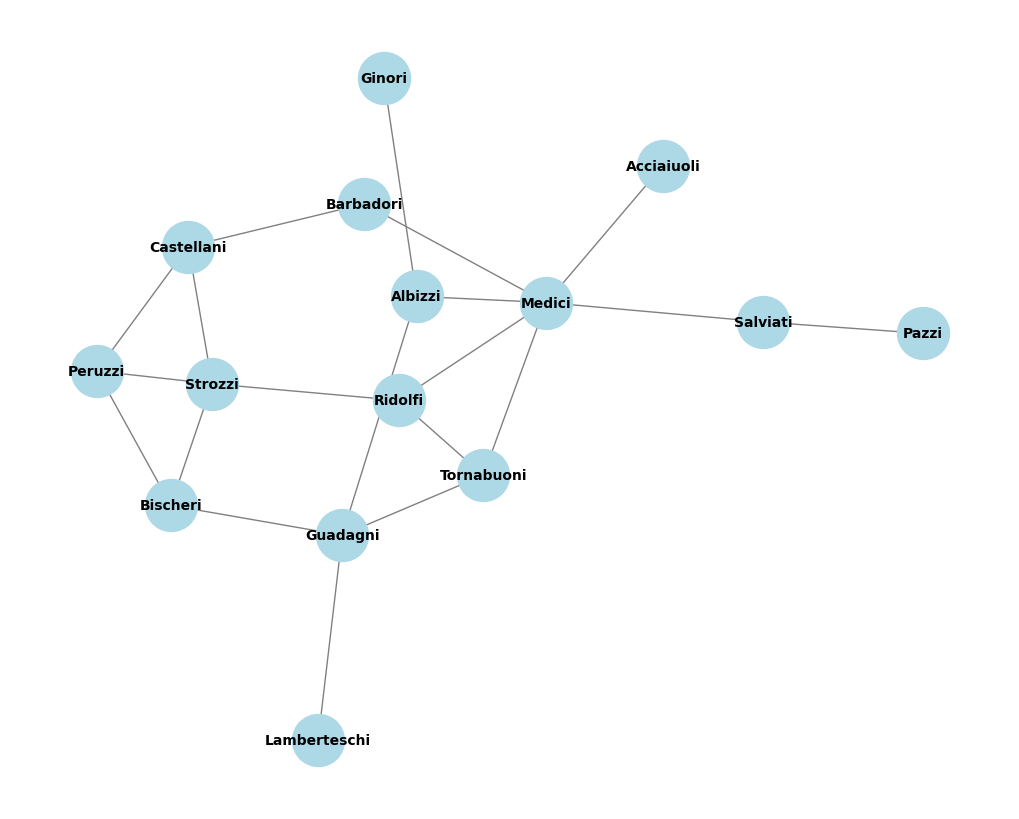

In [ ]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=1400,
    edge_color="gray",
    font_size=10,
    font_weight="bold"
)

plt.show()

Mreža obitelji je neusmjeren i povezan graf što znači da između svake dvije obitelji postoji put. Gustoća grafa je relativno mala te su obitelji međusobno izravno povezane te postoju samo neke važne veze.

Obitelj Medici ima najveći broj veza te ima važnu ulogu u mreži. Najkraći put između obitelji Medici i Strozzi pokazuje da neke obitelji nisu povezane izravno, nego preko drugih obitelji. Ciklus u mreži pokazuje da postoje skupine obitelji koje su međusobno povezane u krugu.

Iz prikaza grafa vidi se da mreža nije nasumična, nego da neke obitelji imaju važniju i središnju ulogu od drugih.